In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [19]:
np.random.seed(42)

dates = pd.date_range(start="2025-01-01", periods=36, freq='M')

trend = np.linspace(32000, 50000, 36)
seasonality = 2000 * np.sin(np.arange(36) * (2 * np.pi / 12))
noise = np.random.normal(0, 1000, 36)

revenue = trend + seasonality + noise

df = pd.DataFrame({
    "Date": dates,
    "Revenue": revenue
})

df.set_index("Date", inplace=True)
df.head()

/tmp/ipykernel_1516/3365134275.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2025-01-01", periods=36, freq='M')


,Revenue
Date,
2025-01-31,32496.714153
2025-02-28,33376.021413
2025-03-31,35408.310774
2025-04-30,37065.886999
2025-05-31,35555.040290


In [20]:
df["month"] = df.index.month
df["year"] = df.index.year
df["time_index"] = np.arange(len(df))

In [21]:
X = df[["month", "year", "time_index"]]
y = df["Revenue"]

In [22]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [23]:
df["Prediction"] = model.predict(X)

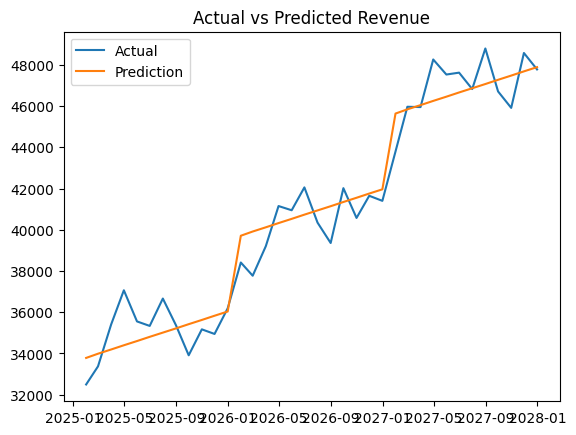

In [24]:
plt.figure()
plt.plot(df.index, df["Revenue"], label="Actual")
plt.plot(df.index, df["Prediction"], label="Prediction")

plt.title("Actual vs Predicted Revenue")
plt.legend()
plt.show()

In [25]:
future_dates = pd.date_range(start=df.index[-1], periods=6, freq='M')

future_df = pd.DataFrame(index=future_dates)

future_df["month"] = future_df.index.month
future_df["year"] = future_df.index.year
future_df["time_index"] = np.arange(len(df), len(df) + 6)

future_df["Forecast"] = model.predict(future_df)

/tmp/ipykernel_1516/3687572221.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df.index[-1], periods=6, freq='M')


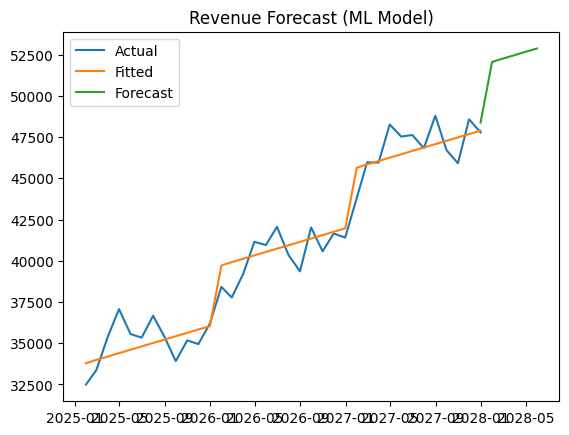

In [26]:
plt.figure()
plt.plot(df.index, df["Revenue"], label="Actual")
plt.plot(df.index, df["Prediction"], label="Fitted")
plt.plot(future_df.index, future_df["Forecast"], label="Forecast")

plt.title("Revenue Forecast (ML Model)")
plt.legend()
plt.show()

In [27]:
growth_rate = 1.1
future_df["Budget"] = future_df["Forecast"] * growth_rate

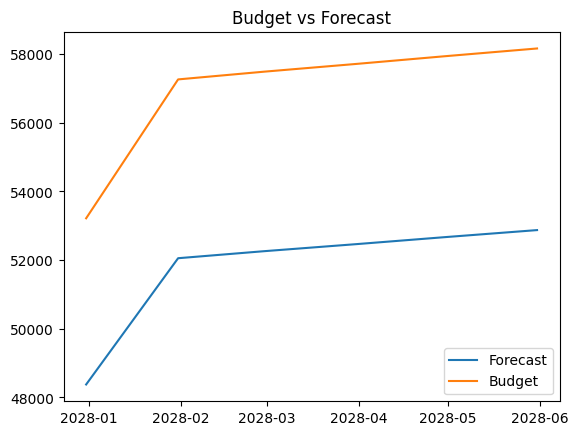

In [28]:
plt.figure()
plt.plot(future_df.index, future_df["Forecast"], label="Forecast")
plt.plot(future_df.index, future_df["Budget"], label="Budget")

plt.title("Budget vs Forecast")
plt.legend()
plt.show()

## 🔍 Insights

-Revenue shows a consistent upward trend over time, indicating steady business growth and increasing demand.
-There is a clear seasonal pattern, where certain periods consistently perform better than others, suggesting cyclical customer behavior.
-The model successfully captures both trend and seasonality, allowing for more reliable and realistic revenue forecasts.
-Forecast results suggest that the business is likely to maintain its growth trajectory in the short term, assuming current conditions remain stable.
-The budget scenario, based on a 10% growth assumption, provides a practical target for planning, but should be monitored against actual performance.